In [1]:
top5=[1, 8, 7, 2, 9]
mapping={}
for id,ele in enumerate(top5):
    mapping[ele]=id+1
print(mapping)

{1: 1, 8: 2, 7: 3, 2: 4, 9: 5}


In [2]:
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import json
import numpy as np

In [3]:
dataset_path='/kaggle/input/datasets/adithip2000/filtered-dataset-zip/filtered_dataset'
annos_path=os.path.join(dataset_path,'annos')
image_path=os.path.join(dataset_path,'image')

In [4]:
print(dataset_path)
!ls -F "{dataset_path}"

/kaggle/input/datasets/adithip2000/filtered-dataset-zip/filtered_dataset
annos/	image/


In [5]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

#Dataset Loater works on cpu so tensor created for mask rcnn is on cpu only

In [6]:
import torch

In [7]:
class MaskRCNNDataset(Dataset):
    def __init__(self,images_dir,annos_dir,transforms=None):
        self.images_dir=images_dir
        self.annos_dir=annos_dir
        self.transforms=transforms
        self.image_files = sorted(os.listdir(images_dir))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self,idx):
        image_name=self.image_files[idx]
        image_path=os.path.join(self.images_dir,image_name)
        annos_name=image_name.replace(".jpg",".json")
        annos_path=os.path.join(self.annos_dir,annos_name)
        
        image=cv2.imread(image_path)
        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
        height,width=image.shape[:2]
        image=cv2.resize(image, (512, 512))
        
        scale_x = 512 / width
        scale_y = 512 / height



        json_dict=dict()
        with open(annos_path) as f:
            json_dict=json.load(f)
        boxes=[]
        labels=[]
        masks=[]

        for item in json_dict:
            obj=json_dict[item]
            old_cat=obj['category_id']
            if old_cat not in mapping:
                continue
            new_cat=mapping[old_cat]
            
            xmin, ymin, xmax, ymax = obj["bounding_box"]

            scaled_xmin = xmin * scale_x
            scaled_xmax = xmax * scale_x
            scaled_ymin = ymin * scale_y
            scaled_ymax = ymax * scale_y

            # Ensure bounding box has positive height and width
            if scaled_xmax > scaled_xmin and scaled_ymax > scaled_ymin:
                labels.append(new_cat)
                mask = np.zeros((512,512), dtype=np.uint8)
                for polygon in obj["segmentation"]:
                    polygon = np.array(polygon).reshape(-1,2).astype(np.float32)

                    polygon[:,0] = polygon[:,0] * scale_x
                    polygon[:,1] = polygon[:,1] * scale_y

                    polygon = polygon.astype(np.int32)

                    cv2.fillPoly(mask, [polygon], 1)
                masks.append(mask)
                boxes.append([scaled_xmin, scaled_ymin, scaled_xmax, scaled_ymax])

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        masks = torch.tensor(np.array(masks), dtype=torch.uint8)

        image = torch.tensor(image, dtype=torch.float32).permute(2,0,1) / 255.0

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks
        }

        return image, target



In [8]:
dataset = MaskRCNNDataset(image_path, annos_path)
print(len(dataset))


144174


What Does collate_fn Do?

Default DataLoader tries to stack everything.

But here we need:

images = [img1, img2, img3, img4]
targets = [t1, t2, t3, t4]

NOT one big stacked tensor.

So collate_fn preserves them as lists.

In [9]:
from torch.utils.data import random_split

train_size = int(0.7 * len(dataset))
test_size = len(dataset) - train_size
generator = torch.Generator().manual_seed(42)

#subset the train dataset

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=generator
)

# subset = torch.utils.data.Subset(train_dataset, range(20000))
# val_sub=torch.utils.data.Subset(train_dataset,range(20000,25000))
# test_sub=torch.utils.data.Subset(val_dataset,range(0,1000))
# randomly choose subset indices
# indices = torch.randperm(len(dataset), generator=generator)

# train_indices = torch.randperm(len(train_dataset), generator=generator)
# train_idx = train_indices[:20000]
# val_idx = train_indices[20000:25000]
# test_idx = torch.arange(1500)

train_idx=torch.load('/kaggle/input/models/adithip2000/indices/pytorch/default/1/train_idx (1).pt')
val_idx=torch.load('/kaggle/input/models/adithip2000/indices/pytorch/default/1/val_idx (1).pt')
test_idx=torch.load('/kaggle/input/models/adithip2000/indices/pytorch/default/1/test_idx (1).pt')

train_sub = torch.utils.data.Subset(train_dataset, train_idx)
val_sub = torch.utils.data.Subset(train_dataset, val_idx)

test_sub = torch.utils.data.Subset(test_dataset,test_idx )

# torch.save(train_idx, "/kaggle/working/train_idx.pt")
# torch.save(val_idx, "/kaggle/working/val_idx.pt")
# torch.save(test_idx, "/kaggle/working/test_idx.pt")


In [10]:
# from collections import Counter

# class_counts = Counter()

# for idx in train_sub.indices:
#     _, target = dataset[idx]
#     labels = target["labels"].tolist()
#     class_counts.update(labels)

# print(class_counts)

In [11]:
# class_weights = {}

# for cls, count in class_counts.items():
#     class_weights[cls] = 1.0 / count

In [12]:
# image_weights=[]
# for idx in train_sub.indices:
#     _, target = dataset[idx]
#     labels = target["labels"].tolist()
#     weight=sum(class_weights[l] for l in labels)/len(labels)
#     image_weights.append(weight)
# print(len(image_weights))

In [13]:
image_weights=torch.load('/kaggle/input/models/adithip/image-weights-train/pytorch/default/1/image_weights.pt')

In [14]:
from torch.utils.data import WeightedRandomSampler

sampler = WeightedRandomSampler(
    weights=image_weights,
    num_samples=len(image_weights),
    replacement=True
)

In [15]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [16]:
from torch.utils.data import DataLoader
#do not use shuffle=true when trying to use sampler
train_loader = DataLoader(
    train_sub,
    batch_size=2,
    sampler=sampler,
    collate_fn=collate_fn,
    num_workers=2
)

val_loader = DataLoader(
    val_sub,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

test_loader = DataLoader(
    test_sub,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

In [17]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor



In [18]:
num_classes=len(top5)+1
model=torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT",min_size=512,max_size=512)



Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 223MB/s]


👍 In short
weights="DEFAULT"
→ full COCO pretrained model
weights_backbone="DEFAULT"
→ only backbone pretrained

In [19]:
#replacing box_boundings and mask part
in_features=model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor=FastRCNNPredictor(in_features,num_classes)

#replacing mask predictors from 80 to 6
in_features_mask=model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor=MaskRCNNPredictor(in_features_mask,256,num_classes)


In [20]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device="cpu"
model.to(device)
print(device)

cuda


In [21]:
# model_scratch.rpn.post_nms_top_n_train = 500
model.rpn.post_nms_top_n_train = 2000
model.rpn.post_nms_top_n_test = 1000
#This controls how many region proposals the RPN keeps after NMS during training.

In [22]:
model.roi_heads.detections_per_img = 300

In [23]:
model.roi_heads.score_thresh = 0.3

In [24]:
# # Freeze backbone layers
# for param in model.backbone.parameters():
#     param.requires_grad = False

# print("Backbone frozen. Only ROI heads and new layers will be trained.")

In [25]:
optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-3,
    momentum=0.9,
    weight_decay=0.0005
)

In [26]:
# #For full fine tuning- method 1 afte method 3
# for param in model.parameters():
#     param.requires_grad = True
# for g in optimizer.param_groups:
#     g["lr"] = 0.001  # smaller LR for fine-tuning

In [27]:
def validation(model,val_loader,device):
    print("Under Validation...........")
    model.train() # Set to train mode to get loss dict, but will be inside no_grad()
    val_loss = 0.0 # Initialize val_loss
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets] # Ensure targets are on device
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            val_loss += losses.item()
    return val_loss/len(val_loader)


In [28]:
def train_one_epoch(model,train_loader,device):
    print("Training........")
    total_img=0
    model.train()
    epoch_loss=0
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        # for k, v in loss_dict.items():
        #     print(k, v.item())

        losses = sum(loss for loss in loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        #clipping gradients for exploding issues, 
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        epoch_loss += losses.item()
        total_img+=1
        if(total_img%1000==0):
            print(f"epoch loss {losses.item()} image {total_img}/10000")
    return epoch_loss/len(train_loader)


In [29]:
# checkpoint=torch.load("/kaggle/input/models/adithip/transfer-epoch-15/pytorch/default/1/transfer_checkpoint_epoch14.pth",map_location=torch.device('cuda'))
checkpoint=torch.load("/kaggle/input/models/adithip2000/best-fine-tuned/pytorch/default/1/transfer_checkpoint_epoch48.pth",map_location=torch.device('cuda'))

model.load_state_dict(checkpoint["model_state_dict"])
# optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

<All keys matched successfully>

In [30]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

def mapPredWhole(model, test_loader, device):
    metric_bbox = MeanAveragePrecision(iou_type=["bbox"])
    metric_segm = MeanAveragePrecision(iou_type=["segm"])

    model.eval()
    for images, targets in test_loader:
        images = [img.to(device) for img in images]

        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        with torch.no_grad():
            preds = model(images)

        for pred in preds:
            masks = pred["masks"].squeeze(1)
            masks = (masks > 0.5).to(torch.uint8)
            pred["masks"] = masks
            
        for t in targets:
            t["masks"] = t["masks"].to(torch.uint8)

        metric_bbox.update(preds,targets)
        metric_segm.update(preds,targets)

    bbox_results=metric_bbox.compute()
    segm_results=metric_segm.compute()

    return bbox_results,segm_results

In [31]:
result_bbox,result_segm=mapPredWhole(model,test_loader,device)
print("BBox----")
print(result_bbox)
print("Segmentation-----")
print(result_segm)

BBox----
{'map': tensor(0.6325), 'map_50': tensor(0.8467), 'map_75': tensor(0.7419), 'map_small': tensor(-1.), 'map_medium': tensor(0.3050), 'map_large': tensor(0.6413), 'mar_1': tensor(0.7297), 'mar_10': tensor(0.7363), 'mar_100': tensor(0.7363), 'mar_small': tensor(-1.), 'mar_medium': tensor(0.3663), 'mar_large': tensor(0.7448), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([1, 2, 3, 4, 5], dtype=torch.int32)}
Segmentation-----
{'map': tensor(0.6368), 'map_50': tensor(0.8450), 'map_75': tensor(0.7567), 'map_small': tensor(-1.), 'map_medium': tensor(0.4530), 'map_large': tensor(0.6540), 'mar_1': tensor(0.7203), 'mar_10': tensor(0.7268), 'mar_100': tensor(0.7268), 'mar_small': tensor(-1.), 'mar_medium': tensor(0.5459), 'mar_large': tensor(0.7417), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([1, 2, 3, 4, 5], dtype=torch.int32)}


In [32]:

def mapPred(model, test_loader, device):
    metric_bbox = MeanAveragePrecision(iou_type=["bbox"],class_metrics=True)
    metric_segm = MeanAveragePrecision(iou_type=["segm"],class_metrics=True)

    model.eval()
    for images, targets in test_loader:
        images = [img.to(device) for img in images]

        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        with torch.no_grad():
            preds = model(images)

        for pred in preds:
            masks = pred["masks"].squeeze(1)
            masks = (masks > 0.5).to(torch.uint8)
            pred["masks"] = masks
            
        for t in targets:
            t["masks"] = t["masks"].to(torch.uint8)

        metric_bbox.update(preds,targets)
        metric_segm.update(preds,targets)

    bbox_results=metric_bbox.compute()
    segm_results=metric_segm.compute()

    return bbox_results,segm_results

In [33]:
print("Test Map")
result_bbox,result_segm=mapPred(model,test_loader,device)


Test Map


In [34]:
class_names= {
    0: "background",
    1: "short sleeve top",
    2: "trousers",
    3: "shorts",
    4: "long sleeve top",
    5: "skirt"
}

In [35]:
def print_class_results(results,class_names):
    classes=results["classes"]
    ap_val=results['map_per_class']
    ar_val=results['mar_100_per_class']

    for cls_id,ap_val,ar_val in zip(classes,ap_val,ar_val):
        cls_id=cls_id.item()
        name=class_names.get(cls_id,f"class_{cls_id}")
        ap_val=ap_val.item()
        ar_val=ar_val.item()
        f1=2*ap_val*ar_val/(ap_val + ar_val + 1e-6)

        print(f"{name:20s} | AP: {ap_val:.4f} | AR: {ar_val:.4f} | F1 {f1:.4f}")
        

In [36]:
print("BBox results")
print_class_results(result_bbox,class_names)
print("Segmentation results")
print_class_results(result_segm,class_names)

BBox results
short sleeve top     | AP: 0.7204 | AR: 0.8107 | F1 0.7629
trousers             | AP: 0.6819 | AR: 0.7429 | F1 0.7111
shorts               | AP: 0.5777 | AR: 0.6631 | F1 0.6175
long sleeve top      | AP: 0.5719 | AR: 0.7278 | F1 0.6405
skirt                | AP: 0.6107 | AR: 0.7369 | F1 0.6679
Segmentation results
short sleeve top     | AP: 0.7260 | AR: 0.8034 | F1 0.7628
trousers             | AP: 0.6840 | AR: 0.7333 | F1 0.7078
shorts               | AP: 0.5997 | AR: 0.6689 | F1 0.6324
long sleeve top      | AP: 0.5676 | AR: 0.7024 | F1 0.6278
skirt                | AP: 0.6067 | AR: 0.7259 | F1 0.6610


In [37]:
img=cv2.imread(os.path.join(image_path,'000900.jpg'))
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

In [38]:
image_tensor = torch.tensor(img/255.0, dtype=torch.float32)
image_tensor = image_tensor.permute(2,0,1)
image_tensor=image_tensor.to(device)
model.eval()

with torch.no_grad():
    predictions = model([image_tensor])

In [39]:
pred = predictions[0]

boxes = pred["boxes"]
scores = pred["scores"]
labels = pred["labels"]
masks = pred["masks"]

In [40]:
# class_names={7:'shorts',1:'short sleeve top',9:'skirt',8:'trousers',2:'long sleeve top'}
# {1: 1, 8: 2, 7: 3, 2: 4, 9: 5}
class_names=['background','short sleeve top','trousers','shorts','long sleeve top','skirt']

In [41]:
import cv2
import numpy as np
import random

img_draw = img.copy()

masks = masks > 0.5   # threshold masks

for i in range(len(boxes)):

    if scores[i] > 0.9:

        # ---- BOX ----
        x1, y1, x2, y2 = boxes[i]
        x1, y1, x2, y2 = map(int, [x1.item(), y1.item(), x2.item(), y2.item()])

        # ---- RANDOM COLOR ----
        color = [random.randint(20,255) for _ in range(3)]

        # ---- MASK OVERLAY ----
        mask = masks[i, 0].cpu().numpy()

        colored_mask = np.zeros_like(img_draw, dtype=np.uint8)
        colored_mask[mask == 1] = color

        alpha = 0.7
        img_draw = cv2.addWeighted(img_draw, 1, colored_mask, alpha, 0)

        # ---- DRAW BOX ----
        cv2.rectangle(img_draw, (x1,y1), (x2,y2), color, 2)

        # ---- LABEL FIX (IMPORTANT) ----
        label_id = labels[i].item()  
        label_name = class_names[label_id]

        text = f"{label_name} {scores[i]:.2f}"

        # ---- TEXT BACKGROUND ----
        (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)

        text_y = max(y1 - 10, th + 5)

        # filled rectangle for readability
        cv2.rectangle(img_draw,
                      (x1, text_y - th - 5),
                      (x1 + tw, text_y),
                      color,
                      -1)

        # put text
        cv2.putText(img_draw,
                    text,
                    (x1, text_y - 2),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255,255,255),
                    1)

In [42]:
# cv2.imwrite("prediction3.jpg", cv2.cvtColor(img_draw, cv2.COLOR_RGB2BGR))

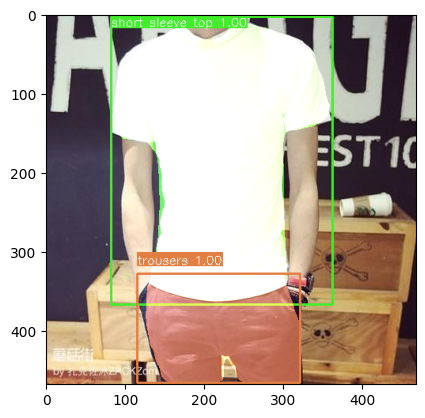

In [43]:
plt.imshow(img_draw)

In [44]:
import torch

def overlay_mask_torch(image, mask, color=(0, 1, 0), alpha=0.5):
    """
    image: [3, H, W] (float, 0-1)
    mask: [H, W] (0/1)
    """
    color = torch.tensor(color).view(3, 1, 1).to(image.device)
    
    mask = mask.unsqueeze(0)  # [1, H, W]
    
    overlay = image.copy()
    overlay = torch.where(mask.bool(), color, overlay)
    
    output = image * (1 - alpha) + overlay * alpha
    
    return output

In [45]:
import torch
import numpy as np
from torchmetrics.classification import BinaryF1Score, MulticlassAUROC

# -------------------------------
# SET DEVICE
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------
# FIND NUMBER OF CLASSES
# -------------------------------
all_labels = []

for _, targets in test_loader:
    for t in targets:
        all_labels.extend(t["labels"].cpu().numpy())

unique_classes = sorted(list(set(all_labels)))
num_classes = len(unique_classes)

print("Classes:", unique_classes)
print("Num Classes:", num_classes)

# mapping (handles labels like 1,2,3)
class_to_idx = {cls: idx for idx, cls in enumerate(unique_classes)}

# -------------------------------
# INIT METRICS
# -------------------------------
f1_metric = BinaryF1Score().to(device)
roc_metric = MulticlassAUROC(num_classes=num_classes).to(device)

dice_scores = []

# -------------------------------
# EVALUATION LOOP
# -------------------------------
model.eval()

with torch.no_grad():
    for images, targets in test_loader:

        # move to device
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        outputs = model(images)

        for i in range(len(outputs)):

            # ===============================
            # SEGMENTATION (Dice + F1)
            # ===============================
            pred_masks = outputs[i]['masks'].squeeze(1)
            true_masks = targets[i]['masks']

            if len(pred_masks) == 0 or len(true_masks) == 0:
                continue

            # combine instance masks
            pred_combined = pred_masks.max(dim=0)[0]
            true_combined = true_masks.max(dim=0)[0]

            pred_bin = (pred_combined > 0.5).int()
            true_bin = (true_combined > 0).int()

            pred_flat = pred_bin.flatten()
            true_flat = true_bin.flatten()

            # ---- Dice (manual)
            intersection = (pred_flat * true_flat).sum()
            dice = (2 * intersection) / (pred_flat.sum() + true_flat.sum() + 1e-8)
            dice_scores.append(dice.item())

            # ---- F1 (same as Dice)
            f1_metric.update(pred_flat, true_flat)

            # ===============================
            # LABEL HEAD (ROC-AUC)
            # ===============================
            pred_labels = outputs[i]['labels']
            scores = outputs[i]['scores']
            true_labels = targets[i]['labels']

            if len(pred_labels) == 0 or len(true_labels) == 0:
                continue

            min_len = min(len(pred_labels), len(true_labels))

            preds = pred_labels[:min_len]
            probs = scores[:min_len]
            targets_ = true_labels[:min_len]

            # map labels to 0-based index
            preds = torch.tensor([class_to_idx[int(p.item())] for p in preds], device=device)
            targets_ = torch.tensor([class_to_idx[int(t.item())] for t in targets_], device=device)

            # create probability matrix
            prob_matrix = torch.zeros((min_len, num_classes), device=device)

            for j in range(min_len):
                prob_matrix[j, preds[j]] = probs[j]

            roc_metric.update(prob_matrix, targets_)

# -------------------------------
# FINAL METRICS
# -------------------------------
mean_dice = np.mean(dice_scores)
f1_score = f1_metric.compute()
roc_auc = roc_metric.compute()

print(f"Dice Score: {mean_dice:.4f}")
print(f"F1 Score: {f1_score.item():.4f}")
print(f"ROC-AUC: {roc_auc.item():.4f}")

Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Num Classes: 5
Dice Score: 0.8778
F1 Score: 0.9030
ROC-AUC: 0.7101


In [46]:
# num_epochs = 120  # start small for testing, 9 first
# torch.cuda.empty_cache()
# # best_loss=50
# best_loss= 0.40659999768435956 
# #best loss after 24th epoch
# count=0
# patience=3

# for epoch in range(24,num_epochs):
#     total_img=0
#     model.train()
#     epoch_loss = 0
#     print(f"{epoch} running...")
#     train_loss=train_one_epoch(model,train_loader,device)
#     val_loss=validation(model,val_loader,device)
#     print(f"train_loss={train_loss},val_loss={val_loss}")
#     if(val_loss<best_loss):
#         print("Saving model....")
#         best_loss=val_loss
#         count=0
#         torch.save(
#             {
#                 "epoch":epoch,
#                 "model_state_dict":model.state_dict(),
#                 "optimizer_state_dict":optimizer.state_dict(),
#             },f"/kaggle/working/transfer_checkpoint_epoch{epoch+1}.pth"
#         )
#     else:
#         print("Not saving.. under patience")
#         count+=1
#     if count >= patience:
#         print("Early stopping triggered")
#         break





In [47]:
# #Fine tuning based on Map:
# num_epochs = 51  # start small for testing, 9 first
# torch.cuda.empty_cache()
# # best_loss=50
# # best_loss= 0.40659999768435956 
# best_map=0
# #best loss after 24th epoch
# count=0
# patience=3

# for epoch in range(41,num_epochs):
#     total_img=0
#     model.train()
#     epoch_loss = 0
#     print(f"{epoch} running...")
#     train_loss=train_one_epoch(model,train_loader,device)
#     # val_loss=validation(model,val_loader,device)
#     val_map=mapPred(model,val_loader,device)['map']
#     print(f"train_loss={train_loss},val_map={val_map}")
#     if(val_map>best_map):
#         print("Saving model....")
#         best_map=val_map
#         count=0
#         torch.save(
#             {
#                 "epoch":epoch,
#                 "model_state_dict":model.state_dict(),
#                 "optimizer_state_dict":optimizer.state_dict(),
#             },f"/kaggle/working/transfer_checkpoint_epoch{epoch+1}.pth"
#         )
#     else:
#         print("Not saving.. under patience")
#         count+=1
#     if count >= patience:
#         print("Early stopping triggered")
#         break





scratch: 18 epochs, 13 trained

transfer: 9 epochs, total 14 epochs total

In [48]:
print("Validation begins")
val_loss=validation(model,test_loader,device)
print(val_loss)



Validation begins
Under Validation...........
0.30033934607108437


In [49]:
# print("num_classes:", num_classes)

# all_labels = set()
# for images, targets in train_loader:
#     for t in targets:
#         for label in t["labels"]:
#             all_labels.add(label.item())

# print("Unique labels:", sorted(all_labels))

In [50]:
# from torch.utils.data import DataLoader

# def collate_fn(batch):
#     return tuple(zip(*batch))

# # Make shuffle=True for training
# loader = DataLoader(dataset,
#                     batch_size=4,
#                     shuffle=False,
#                     collate_fn=collate_fn)

In [51]:
# import os

# save_dir = "/kaggle/working/processed_dataset"
# os.makedirs(save_dir, exist_ok=True)

In [52]:
# count = 0

# for images, targets in loader:

#     for i in range(len(images)):

#         sample = {
#             "image": images[i],
#             "target": targets[i]
#         }

#         torch.save(sample, f"{save_dir}/{count}.pt")
#         count += 1

#         if count % 500 == 0:
#             print(count)

In [53]:
# count=0
# for images, targets in loader:
#     count+=1
#     if (count%500==0 and count!=0):
#         print(count)



    # print(len(images))          # batch size
    # print(len(targets))

    # print(images[0].shape)
    # print(targets[0]["boxes"].shape)

    # break

In [54]:
# image, target = dataset[0]

# print(image.shape)              # (3, H, W)
# print(target["boxes"].shape)    # (N, 4)
# print(target["masks"].shape)    # (N, H, W)
# print(target["labels"])